In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_ROOT = '../../../data'

In [7]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''

    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots()
    
    ax = sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'])

    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 15)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
   
    plt.ylim(plot_kwargs['ylim'])
    fig.suptitle(title, fontsize = 20)
    plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [10]:
results_df = pd.read_csv(f'{DATA_ROOT}/female_male_PCC.csv', index_col = 0)
results_df.columns = ['Female', 'Male']

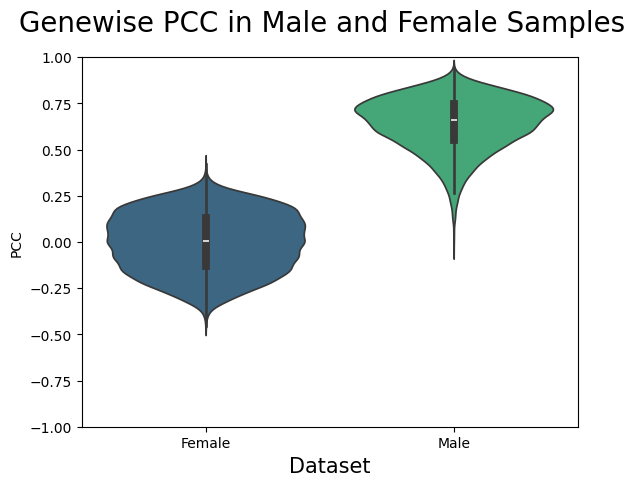

In [17]:
results_df_to_plot = results_df.melt()
results_df_to_plot.columns = ['dataset', 'PCC']
create_pearsons_violin(results_df_to_plot, y_col = 'PCC', title = 'Genewise PCC in Male and Female Samples', file_title = 'female_male_violins')

In [11]:
results_df.melt()

,variable,value
0,Female,-0.139127
1,Female,-0.243343
2,Female,0.129579
3,Female,0.232813
4,Female,0.142016
...,...,...
30489,Male,0.463186
30490,Male,0.709448
30491,Male,0.561248
30492,Male,0.790331
